# Tune GPT2 to generate controlled sentiment reviews
> Optimise GPT2 to produce IMDB movie reviews with controlled sentiment using a BERT sentiment classifier for rewards.

**WARNING:** We often experienced loss spikes in this examples which caused model training to fail or slow down. There is a [GitHub issue](https://github.com/lvwerra/trl/issues/101) to track the issue.

<div style="text-align: center">
<img src='https://huggingface.co/datasets/trl-internal-testing/example-images/resolve/main/images/gpt2-ctrl-training-setup.png' width='600'>
<p style="text-align: center;"> <b>Figure:</b> Experiment setup to tune GPT2. The yellow arrows are outside the scope of this notebook, but the trained models are available through Hugging Face. </p>
</div>


The experiment setup is very similar to the positive sentiment notebook. However, in this notebook we fine-tune GPT2 (small) to generate **controlled** movie reviews based on the IMDB dataset. The model gets the target sentiment and 5 tokens from a real review and is tasked to produce continuations with the targeted sentiment. The reward for the continuations is calculated with the logits of a BERT sentiment classifier. That reward is then used for PPO training.

## Setup experiment

### Import dependencies

In [1]:
# !pip install trl==0.11.4

In [2]:
# %load_ext autoreload
# %autoreload 2

In [3]:
import random
import torch
import wandb
import time
import os
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict
from random import choices
import matplotlib.pyplot as plt
import sys
sys.path.append('/root/autodl-tmp/CommitFit')
from sklearn.model_selection import train_test_split
import ensemble_model.preprocesser as preprocesser 
import ensemble_model.MoE_model as moe 
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, RobertaModel, RobertaTokenizer
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve
import torch.nn.functional as F
tqdm.pandas()
import sys
sys.path.append('/root/autodl-tmp/commit_generative_reinforcement_learning')
# from datasets import load_dataset

from transformers import AutoTokenizer, pipeline, AutoModelForCausalLM

from trl import (
    PPOTrainer,
    PPOConfig,
    AutoModelForCausalLMWithValueHead,
    create_reference_model,
)
from trl import AutoModelForSeq2SeqLMWithValueHead
# from trl.experimental.ppo import PPOTrainer

2026-02-21 20:10:18.618592: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 20:10:18.672527: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 20:10:19.543779: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/root/miniconda3/lib

### Configuration

In [4]:
# commit_pipe_kwargs = {"top_k": None, "function_to_apply": "none"}
batch_size = 4
MODEL_NAME = "/root/autodl-tmp/commit_generative_reinforcement_learning/outputs/checkpoint-2048"
config = PPOConfig(
    model_name=MODEL_NAME,
    steps=51200,
    learning_rate=5e-7,
    remove_unused_columns=False,
    log_with="wandb",
    batch_size=16,
    mini_batch_size=batch_size,
    adap_kl_ctrl=True,
    early_stopping=True,
    whiten_rewards=True,
    target_kl=0.10,   # 例如 0.08~0.12 之间先试
)

txt_in_len = 2048
txt_out_len = 48


/root/autodl-tmp/commit_generative_reinforcement_learning/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(


You can see that we load a GPT2 model called `gpt2_imdb`. This model was additionally fine-tuned on the IMDB dataset for 1 epoch with the huggingface [script](https://github.com/huggingface/transformers/blob/master/examples/run_language_modeling.py) (no special settings). The other parameters are mostly taken from the original paper ["Fine-Tuning Language Models from Human Preferences"](
https://huggingface.co/papers/1909.08593). This model as well as the BERT model is available in the Huggingface model zoo [here](https://huggingface.co/models). The following code should automatically download the models.

## Load data and models

### Load pre-trained GPT2 language models

We load the GPT2 model with a value head and the tokenizer. We load the model twice; the first model is optimized while the second model serves as a reference to calculate the KL-divergence from the starting point. This serves as an additional reward signal in the PPO training to make sure the optimized model does not deviate too much from the original language model.

In [5]:
policy_name = config.model_name
tokenizer = AutoTokenizer.from_pretrained(policy_name)

# 1) policy / ref policy: Seq2Seq + value head
policy = AutoModelForSeq2SeqLMWithValueHead.from_pretrained(policy_name)
ref_policy = AutoModelForSeq2SeqLMWithValueHead.from_pretrained(policy_name)

In [6]:
policy.config.pad_token_id = tokenizer.pad_token_id
policy.config.eos_token_id = tokenizer.eos_token_id

In [7]:
# 确保 eos_token_id 是正数
print("eos_token_id:", tokenizer.eos_token_id)
print("pad_token_id:", tokenizer.pad_token_id)

eos_token_id: 2
pad_token_id: 0


### Load IMDB dataset
The IMDB dataset contains 50k movie review annotated with "positive"/"negative" feedback indicating the sentiment.  We load the IMDB dataset into a DataFrame and filter for comments that are at least 500 characters long and take the first 1000 characters of each comment. The first filter we apply to avoid comments that are less than `txt_in_len` token long and the second to avoid tokenizing way more text than we actually need.

In [8]:
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
# =========================
# 0) 配置
# =========================
CSV_PATH = "data.with_changescribe.csv"


# =========================
# 2) 读 CSV -> Dataset -> split
# =========================
df = pd.read_csv(CSV_PATH)
label2id={'Adaptive':0, 'Corrective':1, 'Perfective':2}
df = df.replace({"labels": label2id})
df

PROMPT_PREFIX = """You are an experienced software engineer writing a Git commit subject line.

Write a concise commit message that summarizes the main intent of the following changes.

Constraints:
- One sentence only.
- Use imperative mood.
- Focus on the main intent (e.g., rename, fix, add, remove, refactor).
- Do not include file paths.
- Do not include explanations.
- Do not include quotes or markdown.

Changes:
"""

PROMPT_SUFFIX = "\n\nCommit message:"
import re

def clean_changescribe(s: str) -> str:
    s = re.sub(r"ChangeScribeStart", "", s)
    s = re.sub(r"Summarized Code Changes:", "", s)
    s = re.sub(r"End change part", "", s)
    return s.strip()

# df["clean_changescribe"] = df["changescribe_text"].fillna("").map(clean_changescribe)

# df["gen_prompt"] = df["clean_changescribe"].map(
#     lambda s: PROMPT_PREFIX + s + PROMPT_SUFFIX
# )


df["gen_prompt"] = df["changescribe_text"].fillna("").map(
    lambda s: PROMPT_PREFIX + s.strip() + PROMPT_SUFFIX
)



df = df.rename(columns={'gt_clean':'target_text','gen_prompt':'source_text'})
label2id={'Adaptive':0, 'Corrective':1, 'Perfective':2}
df = df.replace({"labels": label2id})

df.dropna(inplace=True)
df

,user,repo,commit,labels,msgs,diffs,feature,target_text,changescribe_text,core_diff,source_text
0,ponsonio,RxJava,0531b8bff5c14d9504beefb4ad47f473e3a22932,2,Change hasException to hasThrowable--,diff --git a/rxjava-core/src/main/java/rx/Noti...,"[1, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Change hasException to hasThrowable,RxJava [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: java/rx/Notifi...,You are an experienced software engineer writi...
1,ponsonio,RxJava,0950c46beda335819928585f1262dfe1dca78a0b,0,Trying to extend the Scheduler interface accor...,diff --git a/rxjava-core/src/main/java/rx/Sche...,"[2, 44, 0, 0, 30, 0, 0, 1, 18, 0, 0, 0, 0, 0, ...",Trying to extend the Scheduler interface accor...,RxJava [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: java/rx/Schedu...,You are an experienced software engineer writi...
2,ponsonio,RxJava,0f92fdd8e6422d5b79c610a7fd8409d222315a49,0,RunAsync method for outputting multiple values--,diff --git a/rxjava-contrib/rxjava-async-util/...,"[2, 53, 0, 0, 42, 0, 0, 1, 45, 1, 0, 0, 0, 0, ...",RunAsync method for outputting multiple values,RxJava [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: util/async/Asy...,You are an experienced software engineer writi...
3,ponsonio,RxJava,100f571c9a2835d5a30a55374b9be74c147e031f,1,forEach with Action1 but not Observer--I re-re...,diff --git a/language-adaptors/rxjava-groovy/s...,"[1, 5, 122, 9, 10, 9, 4, 1, 5, 18, 2, 0, 0, 0,...",forEach with Action1 but not Observer I re-rea...,RxJava [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: lang/groovy/Ob...,You are an experienced software engineer writi...
4,ponsonio,RxJava,191f023cf5253ea90647bc091dcaf55ccdce81cc,1,1.x: Fix Completable swallows- OnErrorNotImple...,diff --git a/src/main/java/rx/Completable.java...,"[1, 1, 0, 0, 0, 0, 0, 1, 21, 0, 0, 0, 0, 0, 0,...",1.x: Completable swallows OnErrorNotImplemente...,RxJava [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: java/rx/Comple...,You are an experienced software engineer writi...
...,...,...,...,...,...,...,...,...,...,...,...
1776,jenkinsci,clearcase-plugin,51e9da224f80254476a7dc446bca817b505381d8,2,Use a temporary file to decrease memory consum...,diff --git a/src/main/java/hudson/plugins/clea...,"[2, 12, 0, 4, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,...",Use a temporary file to decrease memory consum...,clearcase-plugin [Change] ChangeScribeStart\nS...,Summarized Code Changes:\nFile: plugins/clearc...,You are an experienced software engineer writi...
1777,jexp,batch-import,609d6c4b1eea2c33d9fb950fcbb9ba9dc1f80fc3,2,added a more memory efficient structure for st...,diff --git a/src/main/java/org/neo4j/batchimpo...,"[10, 159, 29, 35, 9, 2, 1, 5, 106, 0, 4, 8, 0,...",added a more memory efficient structure for st...,batch-import [Change] ChangeScribeStart\nSumma...,Summarized Code Changes:\nFile: neo4j/batchimp...,You are an experienced software engineer writi...
1778,hdiv,hdiv,19b650c78a1c76f4fd90274d7f163f863c0d39e4,2,Memory and performance optimizations,diff --git a/hdiv-config/src/main/java/org/hdi...,"[31, 302, 131, 140, 170, 89, 53, 7, 88, 14, 17...",Memory and performance optimizations,hdiv [Change] ChangeScribeStart\nSummarized Co...,Summarized Code Changes:\nFile: config/xml/Con...,You are an experienced software engineer writi...
1779,casidiablo,persistence,d7bf95159df37a3d338ca267dddd3d26b38ec37c,2,Now it is possible to specify the sqlite open ...,diff --git a/pom.xml b/pom.xml\nindex 394263b....,"[5, 57, 20, 9, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",Now it is possible to specify the sqlite open ...,persistence [Change] ChangeScribeStart\nSummar...,Summarized Code Changes:\nFile: pom.xml\n - Mo...,You are an experienced software engineer writi...


In [9]:

train, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val, test = train_test_split(temp_df, test_size=0.5, random_state=42)

train_dataset = Dataset.from_pandas(train)
valid_dataset = Dataset.from_pandas(val)
test_dataset = Dataset.from_pandas(test)

ds_splits = DatasetDict({
    "train": train_dataset,
    "valid": valid_dataset,
    "test":  test_dataset,
})

# =========================
# 4) 只处理 train split
# =========================
train_ds = ds_splits["train"]

train_ds = train_ds.map(
    lambda x: {
        "input_ids": tokenizer.encode(
            x["source_text"],
            truncation=True,
            max_length=txt_in_len,
        )
    },
    batched=False,
)

train_ds = train_ds.map(
    lambda x: {
        "query": tokenizer.decode(x["input_ids"], skip_special_tokens=False)
    },
    batched=False,
)

# =========================
# 5) 设置 PyTorch 格式
# =========================
train_ds.set_format(
    type="torch",
    columns=["input_ids", "query","labels","changescribe_text","target_text"],  # ✅ 加上 query
)

print(train_ds)
print(train_ds[0])

Map:   0%|          | 0/1022 [00:00<?, ? examples/s]

Map:   0%|          | 0/1022 [00:00<?, ? examples/s]

Dataset({
    features: ['user', 'repo', 'commit', 'labels', 'msgs', 'diffs', 'feature', 'target_text', 'changescribe_text', 'core_diff', 'source_text', '__index_level_0__', 'input_ids', 'query'],
    num_rows: 1022
})
{'labels': tensor(2), 'target_text': 'Efficient InMemory Storage for Vertices', 'changescribe_text': 'hama [Change] ChangeScribeStart\nSummarized Code Changes:\nFile: hama/examples/SSSP.java\n - Modify hama/examples/SSSP.java (1 deletion, 0 additions)\nFile: hama/graph/DiskVerticesInfo.java\n - Rename identifier `Configuration` to `HamaConfiguration` (2 occurrences) in hama/graph/DiskVerticesInfo.java\nFile: hama/graph/GraphJobRunner.java\n - Remove method call `setRunner()` in hama/graph/GraphJobRunner.java\nFile: hama/graph/IDSkippingIterator.java\n - Modify arguments list when calling `hasNext` (0→2 args) in hama/graph/IDSkippingIterator.java\n - Modify arguments list when calling `hasNext` (2→0 args) in hama/graph/IDSkippingIterator.java\nFile: hama/graph/ListVertice

In [10]:
# train_ds['query']

### Tokenize IMDB reviews

We tokenize all IMDB in advance to avoid tokenizing twice. In the first step we encode the queries and slice the first `txt_in_len` tokens. In a second step we decode these tokens back to text for later display.

In [11]:
# dataset[3]["input_ids"]

In [12]:
def collator(data):
    return dict((key, [d[key] for d in data]) for key in data[0])

In [13]:
ppo_trainer = PPOTrainer(
    config, policy, ref_policy, tokenizer, train_ds, data_collator=collator
)

/root/autodl-tmp/commit_generative_reinforcement_learning/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: tongjiajun1992 (tongjiajun1992-china-university-of-mining-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Load BERT classifier
We load a BERT classifier fine-tuned on the IMDB dataset.

In [14]:
from transformers import AutoModelForSequenceClassification
# 自动选择设备（GPU 优先）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load BERT and CodeBERT models and tokenizers
bert_model = BertModel.from_pretrained('/root/autodl-tmp/models/google-bert/bert-base-uncased')
bert_tokenizer = BertTokenizer.from_pretrained('/root/autodl-tmp/models/google-bert/bert-base-uncased')

codebert_model = RobertaModel.from_pretrained('/root/autodl-tmp/models/codebert-base')
codebert_tokenizer = RobertaTokenizer.from_pretrained('/root/autodl-tmp/models/codebert-base')

# 加载
ckpt = torch.load("/root/autodl-tmp/commit_generative_reinforcement_learning/reward_model_combined-3.pt")
# 重新构建结构（必须和训练时一致）
base_model1 = moe.BaseModel(bert_model)
base_model2 = moe.BaseModel(codebert_model)
reward_model = moe.MoEModel(
    base_model1=base_model1,
    base_model2=base_model2
    # hidden_dim=???  如果你的 __init__ 需要，就得你自己传训练时的值
).to(device)

reward_model.load_state_dict(ckpt["model_state_dict"])
reward_model.eval()

MoEModel(
  (base_model1): BaseModel(
    (transformer_model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bi

In [15]:
id2label = {
    0: "Adaptive",
    1: "Corrective",
    2: "Perfective",
}

In [16]:
@torch.no_grad()
def commit_pipe(messages, diffs, batch_size=16):
    """
    messages: List[str]
    diffs:    List[str]
    return:   List[Dict]  (和 HF pipeline 输出风格一致)
    """
    outputs = []

    for i in range(0, len(messages), batch_size):
        batch_msg = messages[i:i+batch_size]
        batch_diff = diffs[i:i+batch_size]

        msg_inputs = bert_tokenizer(
            batch_msg,
            padding=True,
            truncation=True,
            return_tensors="pt",
        ).to(device)

        diff_inputs = codebert_tokenizer(
            batch_diff,
            padding=True,
            truncation=True,
            return_tensors="pt",
        ).to(device)

        logits, _ = reward_model(
            msg_inputs,
            diff_inputs,
        )

        probs = torch.softmax(logits, dim=-1)
        scores, labels = probs.max(dim=-1)

        for j, (s, l, p) in enumerate(zip(scores, labels, probs)):
            outputs.append(
                {
                    "label": id2label[l.item()],
                    "score": s.item(),
                    "probs": p.tolist(),
                    "logits": logits[j].detach().cpu().tolist(),  # ✅加这一行（需要你在循环里有 j）
                }
            )

    return outputs


In [17]:
train['source_text'], train['target_text'], train['labels']

(1772    You are an experienced software engineer writi...
 1070    You are an experienced software engineer writi...
 1240    You are an experienced software engineer writi...
 653     You are an experienced software engineer writi...
 937     You are an experienced software engineer writi...
                               ...                        
 1447    You are an experienced software engineer writi...
 1614    You are an experienced software engineer writi...
 1168    You are an experienced software engineer writi...
 1779    You are an experienced software engineer writi...
 1443    You are an experienced software engineer writi...
 Name: source_text, Length: 1022, dtype: object,
 1772              Efficient InMemory Storage for Vertices
 1070            driver/0.11.0: Add support for attributes
 1240    322734: changed labels, border for rating comment
 653     The ServletContextAdapter passed by the Server...
 937     minor issue in MockHttpServletRequest Previous...
       

In [18]:
# diff_compact

In [19]:
# # id2label = {
# #     0: "Adaptive",
# #     1: "Perfective",
# #     2: "Corrective",
# # }

# text = train['target_text'][1507]
# diff = train['source_text'][1507]  # 这里放真实 diff 文本也可以

# output = commit_pipe([text], [diff])  # 注意：都要用 list 包起来
# print(output[0])

The model outputs are the logits for the negative and positive class. We will use the logits for positive class as a reward signal for the language model.

In [20]:
text = train['target_text'][1130]
diff = train['source_text'][1130]  # 这里放真实 diff 文本也可以

output = commit_pipe([text], [diff])  # 注意：都要用 list 包起来
print(output[0])

{'label': 'Perfective', 'score': 0.9945604205131531, 'probs': [0.004962057340890169, 0.0004776114074047655, 0.9945604205131531], 'logits': [-0.964887261390686, -3.3056654930114746, 4.335593223571777]}


In [21]:
text = train['target_text'][1459]
diff = train['source_text'][1459]  # 这里放真实 diff 文本也可以

output = commit_pipe([text], [diff])  # 注意：都要用 list 包起来
print(output[0])

{'label': 'Corrective', 'score': 0.728062093257904, 'probs': [0.2514882981777191, 0.728062093257904, 0.020449552685022354], 'logits': [0.6932487487792969, 1.7562386989593506, -1.8161866664886475]}


In [22]:
text = "RunAsync method for outputting multiple values--"
diff = ".."  # 这里放真实 diff 文本也可以
output = commit_pipe([text], [diff])  # 注意：都要用 list 包起来
output

[{'label': 'Corrective',
  'score': 0.4254087507724762,
  'probs': [0.32235395908355713, 0.4254087507724762, 0.25223731994628906],
  'logits': [-0.027077317237854004, 0.25032299757003784, -0.2723570168018341]}]

The resulting reward signal:

### Control token dict
We will append the control token at the beginning of each query to signal the model what the target sentiment is. Each control sequence consists of three tokens:

In [23]:
# # import torch
# # 定义控制标签
# 实际没用上
ctrl_str = ["[Adaptive]", "[Corrective]", "[Perfective]"]


In [24]:
ctrl_str

['[Adaptive]', '[Corrective]', '[Perfective]']

### Reward function

In [25]:
num_labels = 3

The following examples show the rewards for the cases where the classifier logit is 4, -4 and 0 for the three targets ['Adaptive','Perfective','Corrective']. The scaling is not perfect as it differs between neutral and the other two classes. This is something to further investigate in the future. Ideally, one would use the logit output for each class individually, but since there is no dedicated class for neutral this is a workaround.

### Generation settings

In [26]:
generation_kwargs = {
    "min_length": 1,   # -1 会报错，改成 1 或 0
    "top_k": 0,        # 设为 0 表示不启用 top-k
    "top_p": 1.0,
    "do_sample": True,
    "pad_token_id": tokenizer.eos_token_id,
    "max_new_tokens": txt_out_len,
    "eos_token_id": tokenizer.eos_token_id,
}

## Optimize model

**Steps**

The training loop consists of the following steps:
1. Get a batch of queries and create random controls
2. Get the query responses from the policy
3. Join query and responses and tokenize for BERT analysis
4. Get sentiments for query/responses from BERT
5. Optimize policy with PPO using the (query, response, reward) triplet
6. Log all the training statistics

**Training time**

This step takes **~2h** on a P6000 GPU with the above specified settings.

In [27]:
# repetition ratio (0~1)
def rep_ratio(text, n=2):
    toks = text.lower().split()
    if len(toks) < n+1:
        return 0.0   # ✅短句不判重复
    ngrams = [tuple(toks[i:i+n]) for i in range(len(toks)-n+1)]
    uniq = len(set(ngrams))
    return float(1.0 - uniq / (len(ngrams) + 1e-6))

def length_score(words: torch.Tensor, lo=6.0, hi=20.0, hard=35.0):
    # [lo, hi] -> 0..1
    up = torch.clamp((words - lo) / (hi - lo), 0.0, 1.0)

    # (hi, hard] -> 1..0
    down = torch.clamp((hard - words) / (hard - hi), 0.0, 1.0)

    # 组合：在 <=hi 用 up，在 >hi 用 down
    base = torch.where(words <= hi, up, down)

    # >hard 直接负分（惩罚超长）
    over = torch.clamp((words - hard) / hard, 0.0, 1.0)
    return base - 0.5 * over


import re

URL_RE   = re.compile(r"https?://\S+|www\.\S+", re.I)
CODE_RE  = re.compile(r"```|~~~|<script|</script>|</?html|</?body", re.I)
WEIRD_RE = re.compile(r"[\uFFFD]")  # replacement char

def garbage_flag(t: str) -> int:
    if t is None:
        return 1
    s = t.strip()
    if len(s) == 0:
        return 1

    # 链接 / 代码块 / HTML 注入痕迹（这些对 commit message 基本都属于坏）
    if URL_RE.search(s) or CODE_RE.search(s):
        return 1

    # 非常“怪”的字符（可按你的语料再加）
    if WEIRD_RE.search(s):
        return 1

    # 标点占比太高（像 "!!!!" / "-----" 这种）
    punct = sum(ch in r"""`~!@#$%^&*()-_=+[]{}\|;:'",.<>/?""" for ch in s)
    if punct / max(1, len(s)) > 0.45:
        return 1

    # 字符重复（aaaaaa、======、。。。。。。）
    max_run = 1
    run = 1
    for i in range(1, len(s)):
        if s[i] == s[i-1]:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 1
    if max_run >= 8:
        return 1

    return 0


def _to_long_tensor(x, device):
    if torch.is_tensor(x):
        return x.to(device).long()
    return torch.tensor(x, device=device).long()

def _ensure_2d_logits(pipe_out, device):
    # pipe_out: list[dict], each dict has "logits" (list/np/tensor)
    logits_list = []
    for o in pipe_out:
        lg = o.get("logits", None)
        if lg is None:
            raise ValueError(f"commit_pipe output missing 'logits': keys={list(o.keys())}")
        if torch.is_tensor(lg):
            lg = lg.detach().to("cpu").float().tolist()
        logits_list.append(lg)
    logits = torch.tensor(logits_list, dtype=torch.float32, device=device)
    if logits.ndim != 2:
        raise ValueError(f"logits must be 2D [B,C], got shape={tuple(logits.shape)}")
    return logits

In [28]:
generation_kwargs.update({
    "min_new_tokens": 4,                 # 关键：避免 0 长度
    "max_new_tokens": 64,
    "eos_token_id": tokenizer.eos_token_id,
    "pad_token_id": tokenizer.pad_token_id,
})


========== Epoch 1/3 ==========


  0%|          | 0/63 [00:00<?, ?it/s]

You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `m

rm_acc: real_msg=1.000 | gen_msg=1.000
[step=0001 i=0] words= 3 logp_true=-0.036 r_cls=+0.967 len=+0.000 rep=0.000 final=-1.962
[step=0001 i=1] words=14 logp_true=-0.004 r_cls=+0.997 len=+0.571 rep=0.000 final=+1.080
[step=0001 i=2] words=23 logp_true=-0.012 r_cls=+0.989 len=+0.800 rep=0.000 final=+1.128
[step=0001] reward(mean/std/min/max)=(-0.000/1.000/-1.970/+1.128) | len(mean/med/<=5)=(9.1/8/37.50%) | r_cls(mean/min/max)=(+0.959/+0.816/+0.998)


/tmp/ipykernel_3842/754014991.py:194: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  approx_kl = float(stats.get("ppo/policy/approxkl", 0.0))
/tmp/ipykernel_3842/754014991.py:195: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  policy_kl = float(stats.get("ppo/policy/policykl", 0.0))
/tmp/ipykernel_3842/754014991.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clipfrac  = float(stats.get("ppo/policy/clipfrac", 0.0))


...

rm_acc: real_msg=0.875 | gen_msg=0.875
[step=0061 i=0] words= 6 logp_true=-0.449 r_cls=+0.592 len=+0.000 rep=0.000 final=-0.148
[step=0061 i=1] words= 4 logp_true=-0.004 r_cls=+0.996 len=+0.000 rep=0.000 final=+0.409
[step=0061 i=2] words= 7 logp_true=-0.004 r_cls=+0.997 len=+0.071 rep=0.000 final=+0.494
[step=0061] reward(mean/std/min/max)=(+0.031/0.893/-3.000/+0.525) | len(mean/med/<=5)=(6.1/5/50.00%) | r_cls(mean/min/max)=(+0.717/-1.540/+0.997)
kl(obj)=+0.028 | approxkl=0.006 | policykl=0.001 | clipfrac=0.050


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=0.938 | gen_msg=0.812
[step=0062 i=0] words= 9 logp_true=-0.016 r_cls=+0.986 len=+0.214 rep=0.000 final=+0.458
[step=0062 i=1] words= 5 logp_true=-0.014 r_cls=+0.987 len=+0.000 rep=0.000 final=+0.412
[step=0062 i=2] words= 4 logp_true=-0.017 r_cls=+0.984 len=+0.000 rep=0.000 final=+0.409
[step=0062] reward(mean/std/min/max)=(+0.015/0.953/-3.000/+0.491) | len(mean/med/<=5)=(8.5/6/31.25%) | r_cls(mean/min/max)=(+0.423/-3.767/+0.998)
kl(obj)=+0.123 | approxkl=0.004 | policykl=0.004 | clipfrac=0.041


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=0.875 | gen_msg=0.875
[step=0063 i=0] words= 4 logp_true=-0.003 r_cls=+0.998 len=+0.000 rep=0.000 final=+0.414
[step=0063 i=1] words=10 logp_true=-0.009 r_cls=+0.992 len=+0.286 rep=0.000 final=+0.523
[step=0063 i=2] words= 9 logp_true=-0.010 r_cls=+0.991 len=+0.214 rep=0.000 final=+0.516
[step=0063] reward(mean/std/min/max)=(+0.016/0.950/-3.000/+0.572) | len(mean/med/<=5)=(7.8/8/37.50%) | r_cls(mean/min/max)=(+0.747/-1.021/+0.998)
kl(obj)=+0.168 | approxkl=0.007 | policykl=0.003 | clipfrac=0.053
task counts: Counter({'[Perfective]': 357, '[Adaptive]': 347, '[Corrective]': 304})


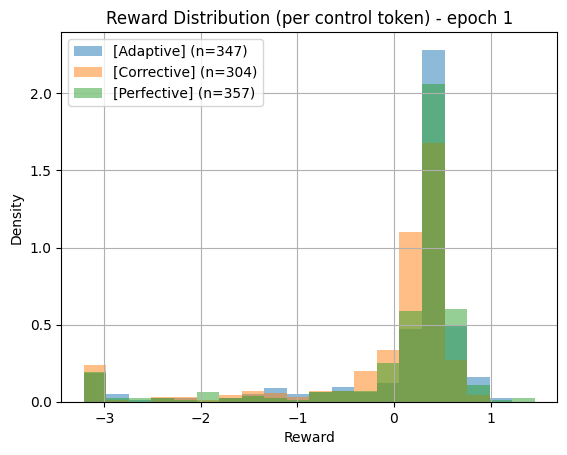


========== Epoch 2/3 ==========


  0%|          | 0/63 [00:00<?, ?it/s]

Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=0.938 | gen_msg=0.875
[step=0001 i=0] words= 6 logp_true=-0.031 r_cls=+0.972 len=+0.000 rep=0.000 final=+0.401
[step=0001 i=1] words=11 logp_true=-0.067 r_cls=+0.939 len=+0.357 rep=0.000 final=+0.391
[step=0001 i=2] words= 3 logp_true=-0.059 r_cls=+0.946 len=+0.000 rep=0.000 final=+0.244
[step=0001] reward(mean/std/min/max)=(+0.024/0.919/-3.000/+0.451) | len(mean/med/<=5)=(10.6/6/37.50%) | r_cls(mean/min/max)=(+0.424/-4.265/+0.998)
kl(obj)=+0.298 | approxkl=0.011 | policykl=-0.000 | clipfrac=0.071


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

rm_acc: real_msg=0.938 | gen_msg=0.875
[step=0061 i=0] words= 8 logp_true=-0.192 r_cls=+0.826 len=+0.143 rep=0.000 final=+0.298
[step=0061 i=1] words= 6 logp_true=-0.157 r_cls=+0.857 len=+0.000 rep=0.000 final=+0.315
[step=0061 i=2] words= 8 logp_true=-6.796 r_cls=-5.186 len=+0.143 rep=0.000 final=-3.000
[step=0061] reward(mean/std/min/max)=(+0.038/0.862/-3.000/+0.404) | len(mean/med/<=5)=(14.3/6/37.50%) | r_cls(mean/min/max)=(+0.409/-5.186/+0.998)
kl(obj)=+0.504 | approxkl=0.005 | policykl=0.000 | clipfrac=0.048


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=0.875 | gen_msg=0.688
[step=0062 i=0] words= 5 logp_true=-0.003 r_cls=+0.997 len=+0.000 rep=0.000 final=+0.493
[step=0062 i=1] words= 7 logp_true=-0.052 r_cls=+0.952 len=+0.071 rep=0.000 final=+0.501
[step=0062 i=2] words= 7 logp_true=-1.051 r_cls=+0.043 len=+0.071 rep=0.000 final=-0.284
[step=0062] reward(mean/std/min/max)=(+0.023/0.925/-3.000/+0.541) | len(mean/med/<=5)=(10.1/7/31.25%) | r_cls(mean/min/max)=(+0.383/-3.517/+0.998)
kl(obj)=+0.736 | approxkl=0.005 | policykl=0.004 | clipfrac=0.040


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=1.000 | gen_msg=0.875
[step=0063 i=0] words= 3 logp_true=-0.002 r_cls=+0.998 len=+0.000 rep=0.000 final=+0.118
[step=0063 i=1] words= 6 logp_true=-0.447 r_cls=+0.593 len=+0.000 rep=0.000 final=-0.248
[step=0063 i=2] words=10 logp_true=-0.003 r_cls=+0.997 len=+0.286 rep=0.000 final=+0.498
[step=0063] reward(mean/std/min/max)=(+0.030/0.896/-3.000/+0.498) | len(mean/med/<=5)=(7.2/6/31.25%) | r_cls(mean/min/max)=(+0.768/-1.241/+0.998)
kl(obj)=+0.196 | approxkl=0.020 | policykl=0.010 | clipfrac=0.053
task counts: Counter({'[Perfective]': 356, '[Adaptive]': 346, '[Corrective]': 306})


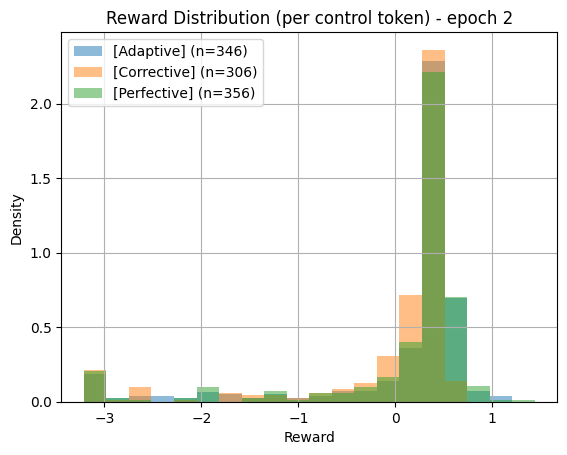


========== Epoch 3/3 ==========


  0%|          | 0/63 [00:00<?, ?it/s]

Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=1.000 | gen_msg=1.000
[step=0001 i=0] words=32 logp_true=-0.016 r_cls=+0.985 len=+0.200 rep=0.000 final=+0.783
[step=0001 i=1] words= 5 logp_true=-0.004 r_cls=+0.996 len=+0.000 rep=0.000 final=+0.476
[step=0001 i=2] words= 4 logp_true=-0.136 r_cls=+0.877 len=+0.000 rep=0.000 final=-0.278
[step=0001] reward(mean/std/min/max)=(+0.003/0.991/-3.000/+0.861) | len(mean/med/<=5)=(7.9/6/37.50%) | r_cls(mean/min/max)=(+0.904/+0.382/+0.998)
kl(obj)=+0.476 | approxkl=0.008 | policykl=0.002 | clipfrac=0.050


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

rm_acc: real_msg=1.000 | gen_msg=0.938
[step=0061 i=0] words=10 logp_true=-0.004 r_cls=+0.997 len=+0.286 rep=0.000 final=+0.592
[step=0061 i=1] words= 4 logp_true=-0.007 r_cls=+0.994 len=+0.000 rep=0.000 final=+0.385
[step=0061 i=2] words= 2 logp_true=-0.463 r_cls=+0.579 len=+0.000 rep=0.000 final=-1.349
[step=0061] reward(mean/std/min/max)=(+0.029/0.903/-3.000/+0.661) | len(mean/med/<=5)=(6.4/5/56.25%) | r_cls(mean/min/max)=(+0.870/-0.108/+0.997)
kl(obj)=-0.214 | approxkl=0.008 | policykl=-0.002 | clipfrac=0.073


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=0.938 | gen_msg=0.938
[step=0062 i=0] words= 4 logp_true=-0.006 r_cls=+0.994 len=+0.000 rep=0.000 final=+0.280
[step=0062 i=1] words= 3 logp_true=-0.007 r_cls=+0.994 len=+0.000 rep=0.000 final=+0.159
[step=0062 i=2] words= 8 logp_true=-0.111 r_cls=+0.899 len=+0.143 rep=0.000 final=+0.249
[step=0062] reward(mean/std/min/max)=(+0.054/0.791/-3.000/+0.336) | len(mean/med/<=5)=(8.2/5/50.00%) | r_cls(mean/min/max)=(+0.628/-4.167/+0.996)
kl(obj)=+0.486 | approxkl=0.005 | policykl=-0.003 | clipfrac=0.043


Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `min_new_tokens` (=4) and `min_length`(=1) seem to have been set. `min_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


rm_acc: real_msg=1.000 | gen_msg=0.938
[step=0063 i=0] words= 4 logp_true=-0.067 r_cls=+0.939 len=+0.000 rep=0.000 final=+0.216
[step=0063 i=1] words= 9 logp_true=-0.027 r_cls=+0.976 len=+0.214 rep=0.000 final=+0.294
[step=0063 i=2] words= 9 logp_true=-0.003 r_cls=+0.997 len=+0.214 rep=0.000 final=+0.311
[step=0063] reward(mean/std/min/max)=(+0.054/0.791/-3.000/+0.327) | len(mean/med/<=5)=(10.4/9/37.50%) | r_cls(mean/min/max)=(+0.650/-4.155/+0.998)
kl(obj)=+0.178 | approxkl=0.004 | policykl=-0.007 | clipfrac=0.043
task counts: Counter({'[Perfective]': 356, '[Adaptive]': 349, '[Corrective]': 303})


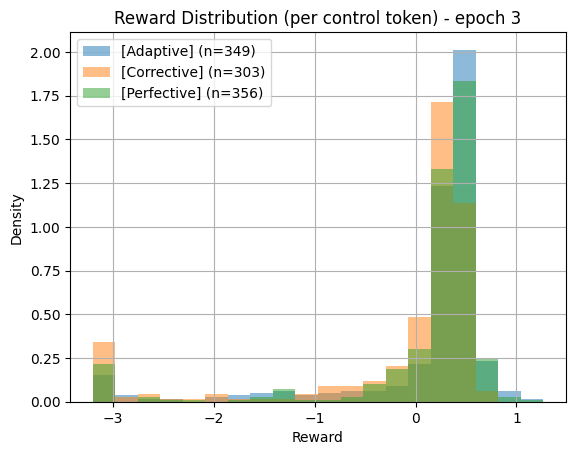

In [29]:
from collections import Counter
import math
n_epochs = 3
C_expected = 3
num_debug = 3

# 你要画的 ctrl 顺序（保持一致）
id2ctrl = {0: "[Adaptive]", 1: "[Corrective]", 2: "[Perfective]"}
ctrl_str = ["[Adaptive]", "[Corrective]", "[Perfective]"]

def _normalize_task_batch(batch, logits_rm=None):
    """
    返回 list[str]，用于 all_tasks 统计/画图。
    优先从 batch 里找 ctrl/task/label；找不到就用 reward model argmax 作为 task（仅用于统计）。
    """
    candidates = ["ctrl", "task", "tasks", "control", "controls", "label", "labels", "y"]
    v = None
    for k in candidates:
        if k in batch:
            v = batch[k]
            break

    # 1) batch 里有字段
    if v is not None:
        # tensor -> list
        if isinstance(v, torch.Tensor):
            v_list = v.detach().cpu().tolist()
        else:
            v_list = list(v)

        # list[str]
        if len(v_list) > 0 and isinstance(v_list[0], str):
            return v_list

        # list[int] -> map
        return [id2ctrl.get(int(i), f"[UNK_{int(i)}]") for i in v_list]

    # 2) batch 没有字段：用 RM argmax 当 task（仅用于画图）
    if logits_rm is None:
        raise KeyError("No ctrl/task/label field in batch, and logits_rm is None.")
    pred = torch.argmax(logits_rm, dim=-1).detach().cpu().tolist()
    return [id2ctrl.get(int(i), f"[UNK_{int(i)}]") for i in pred]


for epoch in range(n_epochs):
    print(f"\n========== Epoch {epoch+1}/{n_epochs} ==========")

    # ✅ 每个 epoch 累积，用于画图/统计
    all_rewards = []
    all_tasks = []

    for step, batch in enumerate(tqdm(ppo_trainer.dataloader), start=1):
        logs, game_data = dict(), dict()

        # ----- queries -----
        game_data["query"] = [q for q in batch["query"]]
        query_tensors = batch["input_ids"]

        # ---- generate ----
        response_tensors = ppo_trainer.generate(query_tensors, **generation_kwargs)

        texts = [
            tokenizer.decode(
                r.squeeze(),
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True
            )
            for r in response_tensors
        ]
        game_data["response"] = texts

        diffs = batch["changescribe_text"]

        # 1) reward model forward (message, diff)
        pipe_out = commit_pipe(texts, diffs, batch_size=batch_size)

        # 2) logits -> tensor [B,C]
        logits_rm = _ensure_2d_logits(pipe_out, device=device)   # [B,C]
        B, C = logits_rm.shape
        if C_expected is not None:
            assert C == C_expected, f"Expected C={C_expected}, got C={C}, logits_shape={tuple(logits_rm.shape)}"

        # =========================
        # cls reward (very smooth): soft margin via logsumexp
        # =========================
        # 1) 取 batch 里的真值标签（必须存在）
        y_true = None
        for k in ["ctrl", "task", "tasks", "control", "controls", "label", "labels", "y"]:
            if k in batch:
                y_true = batch[k]
                break
        if y_true is None:
            raise KeyError("No ground-truth label field in batch. Please ensure dataloader provides labels.")
        
        # 2) 转成 tensor[int64] on device, shape [B]
        if isinstance(y_true, torch.Tensor):
            y_true = y_true.to(device).long()
        else:
            y_true = torch.tensor(list(y_true), device=device).long()
        
        # 3) reward = log p(true_class | diff, msg)
        logp = F.log_softmax(logits_rm, dim=-1)  # [B,C]
        logp_true = logp[torch.arange(B, device=device), y_true]  # <=0
        
        # uniform baseline: log(1/C) = -log(C)
        logp_uni = -math.log(C)
        
        # 归一化到大致 [-1, 1]
        r_cls = (logp_true - logp_uni) / abs(logp_uni)   # >0 表示比均匀猜测更好
        # ===== DEBUG: reward model batch accuracy =====
        with torch.no_grad():
            # 生成 msg 的 acc（你已经有）
            pred_gen = logits_rm.argmax(dim=-1)
            acc_gen = (pred_gen == y_true).float().mean().item()
        
            # 真实 msg 的 acc（新增）
            real_msgs = batch["target_text"]   # ← 改成你真实 msg 的字段名
            pipe_ref = commit_pipe(real_msgs, diffs, batch_size=batch_size)
            logits_ref = _ensure_2d_logits(pipe_ref, device=device)
        
            pred_ref = logits_ref.argmax(dim=-1)
            acc_ref = (pred_ref == y_true).float().mean().item()
        
            print(
                f"rm_acc: real_msg={acc_ref:.3f} | gen_msg={acc_gen:.3f}"
            )
        # =========================
        # shaping
        # =========================
        words = torch.tensor(
            [len(t.strip().split()) for t in texts],
            device=device,
            dtype=torch.float32
        )

        r_len = length_score(words, lo=6.0, hi=20.0, hard=35.0)
        r_rep = torch.tensor([rep_ratio(t, n=2) for t in texts], device=device, dtype=torch.float32)

        raw_final_r = 1.0 * r_cls + 0.05 * r_len - 0.03 * r_rep 
        raw_final_r = raw_final_r - 0.15 * (words <= 3).float()
        raw_final_r = raw_final_r - 0.05 * (words <= 5).float()
        
        # ===== reward whitening only for PPO =====
        final_r = (raw_final_r - raw_final_r.mean()) / (raw_final_r.std(unbiased=False) + 1e-6)
        final_r = torch.clamp(final_r, -3.0, 3.0)
        
        rewards = [ri for ri in final_r]  # PPO 用 whiten 后的

        # optional debug prints
        for i in range(min(num_debug, B)):
            print(
                f"[step={step:04d} i={i}] "
                f"words={int(words[i].item()):2d} "
                f"logp_true={logp_true[i].item():+.3f} "
                f"r_cls={r_cls[i].item():+.3f} "
                f"len={r_len[i].item():+.3f} "
                f"rep={r_rep[i].item():.3f} "
                # f"g={r_g[i].item():.0f} "
                f"final={final_r[i].item():+.3f}"
            )
        # =========================
        # 📊 batch-level diagnostics
        # =========================
        with torch.no_grad():
            # reward stats
            r_mean = final_r.mean().item()
            r_std  = final_r.std(unbiased=False).item()
            r_min  = final_r.min().item()
            r_max  = final_r.max().item()
        
            # length stats
            w_mean = words.mean().item()
            w_med  = words.median().item()
            w_short_ratio = (words <= 5).float().mean().item()
        
            # cls stats
            rcls_mean = r_cls.mean().item()
            rcls_min  = r_cls.min().item()
            rcls_max  = r_cls.max().item()
        
            print(
                f"[step={step:04d}] "
                f"reward(mean/std/min/max)=({r_mean:+.3f}/{r_std:.3f}/{r_min:+.3f}/{r_max:+.3f}) | "
                f"len(mean/med/<=5)=({w_mean:.1f}/{w_med:.0f}/{w_short_ratio:.2%}) | "
                f"r_cls(mean/min/max)=({rcls_mean:+.3f}/{rcls_min:+.3f}/{rcls_max:+.3f})"
            )
        # ✅ 累积 task + reward（detach/cpu/float）
        task_batch = _normalize_task_batch(batch, logits_rm=logits_rm)
        all_tasks.extend(task_batch)
        all_rewards.extend([float(r.detach().cpu().item()) for r in final_r])

        # ---- PPO step ----
        stats = ppo_trainer.step(query_tensors, response_tensors, rewards)
        approx_kl = float(stats.get("ppo/policy/approxkl", 0.0))
        policy_kl = float(stats.get("ppo/policy/policykl", 0.0))
        clipfrac  = float(stats.get("ppo/policy/clipfrac", 0.0))
        
        print(f"kl(obj)={float(stats.get('objective/kl', 0.0)):+.3f} | "
              f"approxkl={approx_kl:.3f} | policykl={policy_kl:.3f} | clipfrac={clipfrac:.3f}")
        
        # two-level guardrail
        warn_th, stop_th = 0.05, 0.10
        if approx_kl > warn_th:
            print(f"[WARN] approxkl high: {approx_kl:.3f} > {warn_th}")
        
        if approx_kl > stop_th:
            print(f"[STOP] approxkl too high -> early stop (>{stop_th}): {approx_kl:.3f}")
            break

        ppo_trainer.log_stats(stats, game_data, rewards)

    # =========================
    # ✅ epoch end: 统计 + 画图
    # =========================
    print("task counts:", Counter(all_tasks))

    if len(all_rewards) > 0:
        xmin, xmax = min(all_rewards), max(all_rewards)
        pad = 1e-6 if xmin == xmax else 0.05 * (xmax - xmin)
        rng = (xmin - pad, xmax + pad)

        plt.figure()
        for ctrl_s in ctrl_str:
            vals = [r for r, t in zip(all_rewards, all_tasks) if t == ctrl_s]
            if len(vals) > 0:
                plt.hist(
                    vals,
                    bins=20,
                    range=rng,
                    density=True,
                    alpha=0.5,
                    label=f"{ctrl_s} (n={len(vals)})",
                )

        plt.legend(loc="best")
        plt.title(f"Reward Distribution (per control token) - epoch {epoch+1}")
        plt.xlabel("Reward")
        plt.ylabel("Density")
        plt.grid(True)
        plt.show()

### Training progress
If you are tracking the training progress with Weights&Biases you should see a plot similar to the following:

<div style="text-align: center">
<img src='https://huggingface.co/datasets/trl-internal-testing/example-images/resolve/main/images/gpt2-ctrl-training-stats.png' width='800'>
<p style="text-align: center;"> <b>Figure:</b> Reward mean and distribution evolution during training. </p>
</div>

One can observe how the model starts to generate more positive outputs after a few optimisation steps.

> Note: Investigating the KL-divergence will probably show that at this point the model has not converged to the target KL-divergence, yet. To get there would require longer training or starting with a higher initial coefficient.

## Model inspection

### Reward distribution
First, we can have a look at the reward distribution. Both the negative and positive rewards are clearly shifted to high rewards. The neutral rewards, however, are still centered around zero. There are a few possible explanations for this. There could be a bug in the code and the way the neutral rewards are calculated. Another problem could be that sentence sometimes start with a strong sentiment and it is hard for the model shift the sentiment towards neutral.

In [30]:
stats.keys()

dict_keys(['objective/kl', 'objective/kl_dist', 'objective/logprobs', 'objective/ref_logprobs', 'objective/kl_coef', 'objective/entropy', 'ppo/mean_non_score_reward', 'ppo/mean_scores', 'ppo/std_scores', 'tokens/queries_len_mean', 'tokens/queries_len_std', 'tokens/queries_dist', 'tokens/responses_len_mean', 'tokens/responses_len_std', 'tokens/responses_dist', 'ppo/loss/policy', 'ppo/loss/value', 'ppo/loss/total', 'ppo/policy/entropy', 'ppo/policy/approxkl', 'ppo/policy/policykl', 'ppo/policy/clipfrac', 'ppo/policy/advantages', 'ppo/policy/advantages_mean', 'ppo/policy/ratio', 'ppo/returns/mean', 'ppo/returns/var', 'ppo/val/vpred', 'ppo/val/error', 'ppo/val/clipfrac', 'ppo/val/mean', 'ppo/val/var', 'ppo/val/var_explained', 'ppo/learning_rate', 'time/ppo/forward_pass', 'time/ppo/compute_rewards', 'time/ppo/compute_advantages', 'time/ppo/optimize_step', 'time/ppo/calc_stats', 'time/ppo/total'])

## Save model
Finally, we save the model to disk for later usage.

In [31]:
policy.save_pretrained("codet5-msgs-ctrl")
tokenizer.save_pretrained("codet5-msgs-ctrl")

('codet5-msgs-ctrl/tokenizer_config.json',
 'codet5-msgs-ctrl/special_tokens_map.json',
 'codet5-msgs-ctrl/vocab.json',
 'codet5-msgs-ctrl/merges.txt',
 'codet5-msgs-ctrl/added_tokens.json',
 'codet5-msgs-ctrl/tokenizer.json')

In [32]:
from simplet5_trl import SimpleT5_TRL
import pandas as pd
model = SimpleT5_TRL()
model.load_model("codet5-msgs-ctrl",use_gpu=True)

Some weights of the model checkpoint at codet5-msgs-ctrl were not used when initializing T5ForConditionalGeneration: ['v_head.summary.bias', 'v_head.summary.weight']
- This IS expected if you are initializing T5ForConditionalGeneration from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing T5ForConditionalGeneration from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [33]:
test

,user,repo,commit,labels,msgs,diffs,feature,target_text,changescribe_text,core_diff,source_text
1543,arquillian,arquillian-graphene,2ce3373d1db087a001b226bccfba43285246a1d4,0,"chrome support added, when the browser is *chr...",diff --git a/api/src/main/java/org/jboss/arqui...,"[6, 28, 13, 1, 20, 27, 1, 0, 0, 0, 0, 0, 0, 0,...","chrome support added, when the browser is *chr...",arquillian-graphene [Change] ChangeScribeStart...,Summarized Code Changes:\nFile: ajocado/framew...,You are an experienced software engineer writi...
44,ponsonio,RxJava,cef0b916c546bf6178b493eafc1ea4adb0357e18,2,1.x: ConcatMapEager allow nulls from inner- Ob...,diff --git a/src/main/java/rx/internal/operato...,"[1, 3, 0, 8, 0, 0, 0, 1, 15, 0, 0, 0, 0, 0, 0,...",1.x: ConcatMapEager allow nulls from inner Obs...,RxJava [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: internal/opera...,You are an experienced software engineer writi...
254,JetBrains,intellij-community,747ce871172baf71ecc0eb8c86f5a0aa4f624b4f,1,StackOverflow fixed--,diff --git a/source/com/intellij/codeInsight/c...,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",StackOverflow fixed,intellij-community [Change] ChangeScribeStart\...,Summarized Code Changes:\nFile: codeInsight/co...,You are an experienced software engineer writi...
1741,hector-client,hector,da1f992b70bd0ae022625624c9c54b57721f4633,2,SlicePredicate: Added support for 'default' ra...,diff --git a/src/main/java/me/prettyprint/cass...,"[1, 11, 1, 8, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",SlicePredicate: Added support for 'default' ra...,hector [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: cassandra/mode...,You are an experienced software engineer writi...
599,JetBrains,kotlin,b40e657180d21655dc6d1ceed6c7726fe7c78071,0,Create from usage: Create constructor paramete...,diff --git a/idea/src/org/jetbrains/kotlin/ide...,"[1, 7, 0, 1, 0, 0, 0, 5, 30, 0, 0, 8, 0, 0, 0,...",Create from usage: Create constructor paramete...,kotlin [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: createFromUsag...,You are an experienced software engineer writi...
...,...,...,...,...,...,...,...,...,...,...,...
1411,GNOME,vala,c447e0cf7766e1914296b648c56eb8d896eb0441,0,dbus-glib-1: Add bindings for DBusGProxy::dest...,diff --git a/vapi/dbus-glib-1.vapi b/vapi/dbus...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",dbus-glib-1: Add bindings for DBusGProxy::dest...,vala [Change] ChangeScribeStart\nSummarized Co...,Summarized Code Changes:\nFile: vapi/dbus-glib...,You are an experienced software engineer writi...
592,JetBrains,kotlin,44d92d8eb39b176c23209f26a69bb1febae8e812,0,Support for checking loaded descriptors agains...,diff --git a/compiler/testData/lazyResolve/dia...,"[0, 0, 0, 0, 0, 0, 0, 411, 13, 0, 9, 0, 0, 0, ...",Support for checking loaded descriptors agains...,kotlin [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: lazyResolve/di...,You are an experienced software engineer writi...
629,restlet,restlet-framework-java,7eb6b0fc4c0975ce708ce97632222ecb1129ed03,2,- Initial code for enhanced internal HTTP- co...,diff --git a/incubator/org.restlet.ext.jxta/ME...,"[33, 40, 1, 34, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, ...",Initial code for enhanced internal HTTP connec...,restlet-framework-java [Change] ChangeScribeSt...,Summarized Code Changes:\nFile: org.restlet.ex...,You are an experienced software engineer writi...
1451,GNOME,vala,93fbeee2b06807a7190b82edb46db3f43f9b84bb,0,glib-2.0: add g_date_set_time_t binding\n,diff --git a/vapi/glib-2.0.vapi b/vapi/glib-2....,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",glib-2.0: add g_date_set_time_t binding,vala [Change] ChangeScribeStart\nSummarized Co...,Summarized Code Changes:\nFile: vapi/glib-2.0....,You are an experienced software engineer writi...


In [34]:
preds = []
for item in tqdm(df["source_text"]):
    res = model.predict(item)[0]
    # print(res)
    preds.append(res)
df["pred"] = preds
df.to_csv("/root/autodl-tmp/commit_generative_reinforcement_learning/generated_commits-ppo.csv", index=False)

  0%|          | 0/1461 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (567 > 512). Running this sequence through the model will result in indexing errors


In [35]:
test

,user,repo,commit,labels,msgs,diffs,feature,target_text,changescribe_text,core_diff,source_text
1543,arquillian,arquillian-graphene,2ce3373d1db087a001b226bccfba43285246a1d4,0,"chrome support added, when the browser is *chr...",diff --git a/api/src/main/java/org/jboss/arqui...,"[6, 28, 13, 1, 20, 27, 1, 0, 0, 0, 0, 0, 0, 0,...","chrome support added, when the browser is *chr...",arquillian-graphene [Change] ChangeScribeStart...,Summarized Code Changes:\nFile: ajocado/framew...,You are an experienced software engineer writi...
44,ponsonio,RxJava,cef0b916c546bf6178b493eafc1ea4adb0357e18,2,1.x: ConcatMapEager allow nulls from inner- Ob...,diff --git a/src/main/java/rx/internal/operato...,"[1, 3, 0, 8, 0, 0, 0, 1, 15, 0, 0, 0, 0, 0, 0,...",1.x: ConcatMapEager allow nulls from inner Obs...,RxJava [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: internal/opera...,You are an experienced software engineer writi...
254,JetBrains,intellij-community,747ce871172baf71ecc0eb8c86f5a0aa4f624b4f,1,StackOverflow fixed--,diff --git a/source/com/intellij/codeInsight/c...,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",StackOverflow fixed,intellij-community [Change] ChangeScribeStart\...,Summarized Code Changes:\nFile: codeInsight/co...,You are an experienced software engineer writi...
1741,hector-client,hector,da1f992b70bd0ae022625624c9c54b57721f4633,2,SlicePredicate: Added support for 'default' ra...,diff --git a/src/main/java/me/prettyprint/cass...,"[1, 11, 1, 8, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",SlicePredicate: Added support for 'default' ra...,hector [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: cassandra/mode...,You are an experienced software engineer writi...
599,JetBrains,kotlin,b40e657180d21655dc6d1ceed6c7726fe7c78071,0,Create from usage: Create constructor paramete...,diff --git a/idea/src/org/jetbrains/kotlin/ide...,"[1, 7, 0, 1, 0, 0, 0, 5, 30, 0, 0, 8, 0, 0, 0,...",Create from usage: Create constructor paramete...,kotlin [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: createFromUsag...,You are an experienced software engineer writi...
...,...,...,...,...,...,...,...,...,...,...,...
1411,GNOME,vala,c447e0cf7766e1914296b648c56eb8d896eb0441,0,dbus-glib-1: Add bindings for DBusGProxy::dest...,diff --git a/vapi/dbus-glib-1.vapi b/vapi/dbus...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",dbus-glib-1: Add bindings for DBusGProxy::dest...,vala [Change] ChangeScribeStart\nSummarized Co...,Summarized Code Changes:\nFile: vapi/dbus-glib...,You are an experienced software engineer writi...
592,JetBrains,kotlin,44d92d8eb39b176c23209f26a69bb1febae8e812,0,Support for checking loaded descriptors agains...,diff --git a/compiler/testData/lazyResolve/dia...,"[0, 0, 0, 0, 0, 0, 0, 411, 13, 0, 9, 0, 0, 0, ...",Support for checking loaded descriptors agains...,kotlin [Change] ChangeScribeStart\nSummarized ...,Summarized Code Changes:\nFile: lazyResolve/di...,You are an experienced software engineer writi...
629,restlet,restlet-framework-java,7eb6b0fc4c0975ce708ce97632222ecb1129ed03,2,- Initial code for enhanced internal HTTP- co...,diff --git a/incubator/org.restlet.ext.jxta/ME...,"[33, 40, 1, 34, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, ...",Initial code for enhanced internal HTTP connec...,restlet-framework-java [Change] ChangeScribeSt...,Summarized Code Changes:\nFile: org.restlet.ex...,You are an experienced software engineer writi...
1451,GNOME,vala,93fbeee2b06807a7190b82edb46db3f43f9b84bb,0,glib-2.0: add g_date_set_time_t binding\n,diff --git a/vapi/glib-2.0.vapi b/vapi/glib-2....,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",glib-2.0: add g_date_set_time_t binding,vala [Change] ChangeScribeStart\nSummarized Co...,Summarized Code Changes:\nFile: vapi/glib-2.0....,You are an experienced software engineer writi...


In [36]:
# df.reset_index(inplace=True)
# test_dataset = preprocesser.SentencePairDataset(test, bert_tokenizer, codebert_tokenizer,message='pred',command='changescribe_text',label='labels')
# # train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# # val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
# test_acc, test_labels, test_probabilities, test_embeddings, test_predictions = reward_model.evaluate(test_loader)

KeyError: 'pred'

In [ ]:
#发送多种类型的邮件
from email.mime.multipart import MIMEMultipart
import smtplib

from email.mime.text import MIMEText
msg_from = '915803745@qq.com'  # 发送方邮箱
passwd = 'vcuosuurrgkfbdai'   #就是上面的授权码
 
# to= ['g.zhang@gotion.com', 'j.tong@gotion.com'] #接受方邮箱
to= ['j.tong@gotion.com'] #接受方邮箱
#设置邮件内容
#MIMEMultipart类可以放任何内容
msg = MIMEMultipart()
conntent=f"{'成功'}"
#把内容加进去
msg.attach(MIMEText(conntent,'plain','utf-8'))
 
#设置邮件主题
msg['Subject']="PPO学习模型训练完毕"
 
#发送方信息
msg['From']=msg_from
 
#开始发送
 
#通过SSL方式发送，服务器地址和端口
s = smtplib.SMTP_SSL("smtp.qq.com", 465)
# 登录邮箱
s.login(msg_from, passwd)
#开始发送
s.sendmail(msg_from,to,msg.as_string())
print("强化学习模型训练完毕")